In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt

In [2]:
mean_predictions = torch.load('outputs/mc_preds/mean_prediction_train.pt')
uncertainties = torch.load('outputs/mc_preds/std_prediction_train.pt')
ys = torch.load('outputs/mc_preds/y_train.pt')
xs = torch.load('outputs/mc_preds/x_train.pt')
errors = torch.load('outputs/mc_preds/true_errors_prediction_train.pt')
ids = torch.load('outputs/mc_preds/ids_train.pt')
mean_predictions = np.array([np.array(item) for sublist in mean_predictions for item in sublist])
uncertainties = np.array([np.array(item) for sublist in uncertainties for item in sublist])
ys = np.array([np.array(item) for sublist in ys for item in sublist])
xs = np.array([np.array(item) for sublist in xs for item in sublist])
errors = np.array([np.array(item) for sublist in errors for item in sublist])
ids = np.array([np.array(item) for sublist in ids for item in sublist])

In [3]:
def _plot_example(pred_mean, pred_std, uncalib_std, error, trgt, inpt, id_, batch_loss, epoch, stage):
    fig, (ax, ax2, ax3) = plt.subplots(3, sharex=True, gridspec_kw={'height_ratios': [6, 2, 2]})
    ax.plot(pred_mean, color="blue", label="pred_mean")
    # plot std around mean
    ax.fill_between(
        np.arange(len(pred_mean)),
        pred_mean - pred_std,
        pred_mean + pred_std,
        color="red",
        alpha=0.2,
        label="std",
    )
    ax.plot(trgt, color="green", label="target (after)")
    ax.plot(inpt, color="black", label="input (before)")
    # ax.plot(error, color="red", label="error", ls="--")
    caption = f"{stage} sample: {id_} - epoch: {epoch} \n batch_loss: {batch_loss:.4f}"
    
    ax2.plot(pred_std, color="orange", label="calib uncertainty (std)", ls="--")
    ax2.plot(uncalib_std, color="black", label="uncalib uncertainty (std)", ls="--")
    
    ax3.plot(error, color="red", label="abs. error", ls="--")
    
    ax.set_title(caption)
    ax.legend()
    ax2.legend()
    ax3.legend()

In [4]:
from sklearn.isotonic import IsotonicRegression

In [5]:
n_samples, n_features = errors.shape
calibrated_uncertainties = np.zeros_like(uncertainties)

for i_feature in range(n_features):
    iso_reg = IsotonicRegression(out_of_bounds='clip')
    iso_reg.fit(uncertainties[:, i_feature], errors[:, i_feature])
    calibrated_uncertainties[:, i_feature] = iso_reg.transform(uncertainties[:, i_feature])

In [12]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(2, 120), max_iter=100, alpha=0.001, solver='adam', verbose=10, tol=1e-5, random_state=1, learning_rate_init=.01)
mlp.fit(uncertainties, errors)
calibrated_uncertainties = mlp.predict(uncertainties)

Iteration 1, loss = 0.05890377
Iteration 2, loss = 0.04517729
Iteration 3, loss = 0.03655615
Iteration 4, loss = 0.03090765
Iteration 5, loss = 0.02763921
Iteration 6, loss = 0.02622888
Iteration 7, loss = 0.02597864
Iteration 8, loss = 0.02613592
Iteration 9, loss = 0.02615783
Iteration 10, loss = 0.02588225
Iteration 11, loss = 0.02542484
Iteration 12, loss = 0.02496484
Iteration 13, loss = 0.02462541
Iteration 14, loss = 0.02443556
Iteration 15, loss = 0.02435686
Iteration 16, loss = 0.02433644
Iteration 17, loss = 0.02432414
Iteration 18, loss = 0.02428369
Iteration 19, loss = 0.02420802
Iteration 20, loss = 0.02409460
Iteration 21, loss = 0.02396139
Iteration 22, loss = 0.02383541
Iteration 23, loss = 0.02373983
Iteration 24, loss = 0.02368582
Iteration 25, loss = 0.02366939
Iteration 26, loss = 0.02367442
Iteration 27, loss = 0.02368060
Iteration 28, loss = 0.02367236
Iteration 29, loss = 0.02364450
Iteration 30, loss = 0.02360223
Iteration 31, loss = 0.02355659
Iteration 32, los

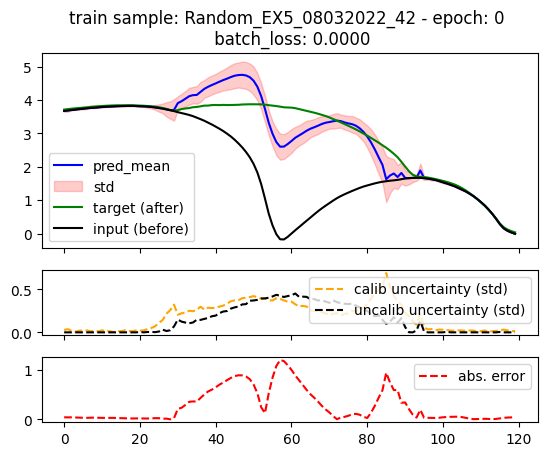

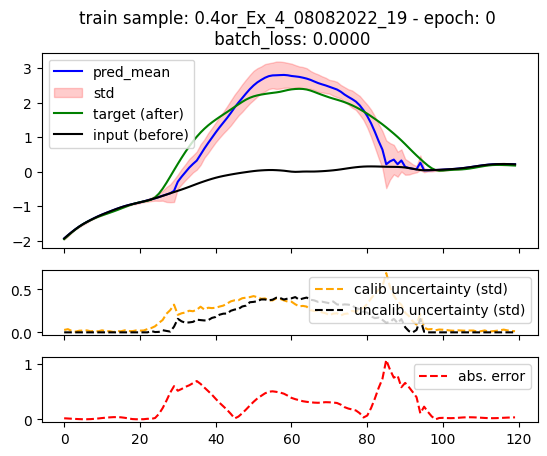

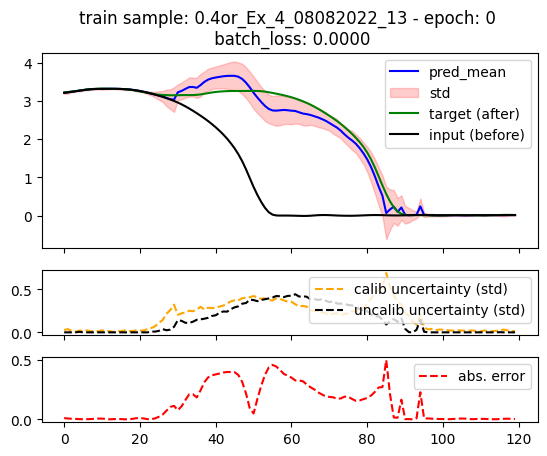

In [15]:
# choose n indices from range(n_samples) at random
n_samples, n_features = errors.shape
n = 3
indices = np.random.choice(range(n_samples), n, replace=False)

for b in indices:
    pred_mean = mean_predictions[b]
    std = uncertainties[b]
    calib_std = calibrated_uncertainties[b]
    error = errors[b]
    trgt = ys[b]
    inpt = xs[b]
    id_ = ids[b]
    batch_loss = 0
    epoch = 0
    stage = "train"
    _plot_example(pred_mean, calib_std, std, error, trgt, inpt, id_, batch_loss, epoch, stage)
    plt.show()

In [48]:
def flatten_(arr):
    arr_out = []
    for b in range(len(arr)):
        batch = np.array(arr[b])
        arr_out.extend(batch)
    
    return np.array(arr_out)
        

In [53]:
val_mean_predictions = torch.load('outputs/mc_preds/mean_prediction_val.pt')
val_uncertainties = torch.load('outputs/mc_preds/std_prediction_val.pt')
val_ys = torch.load('outputs/mc_preds/y_val.pt')
val_xs = torch.load('outputs/mc_preds/x_val.pt')
val_errors = torch.load('outputs/mc_preds/true_errors_prediction_val.pt')
val_ids = torch.load('outputs/mc_preds/ids_val.pt')

val_mean_predictions = flatten_(val_mean_predictions)
val_uncertainties = flatten_(val_uncertainties)
val_ys = flatten_(val_ys)
val_xs = flatten_(val_xs)
val_errors = flatten_(val_errors)
val_ids = flatten_(val_ids)

val_calibrated_uncertainties = mlp.predict(val_uncertainties) 

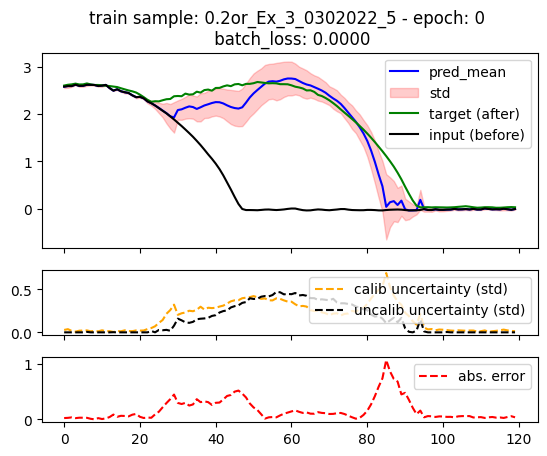

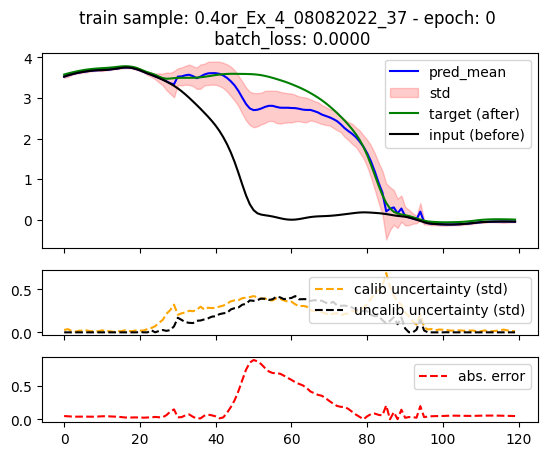

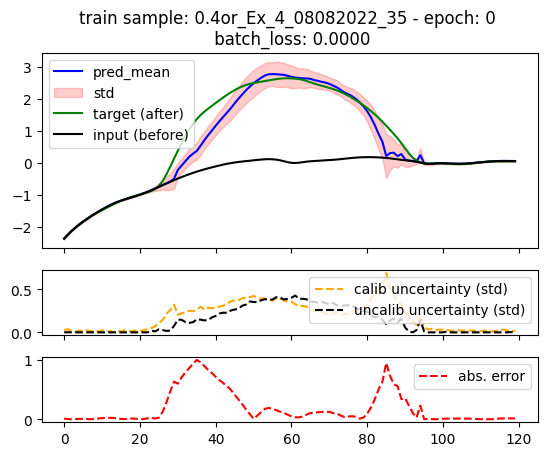

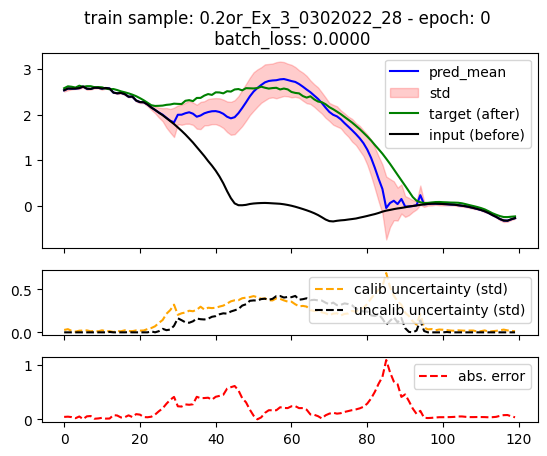

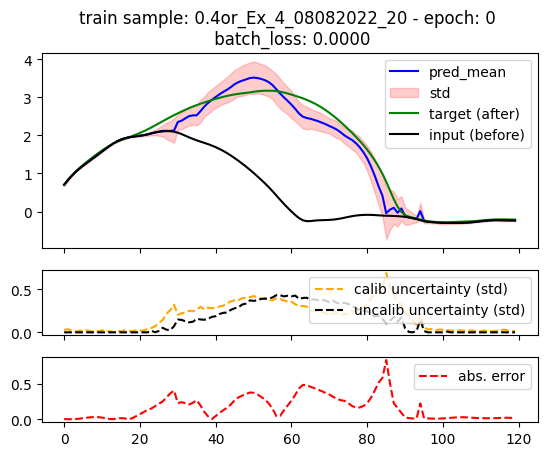

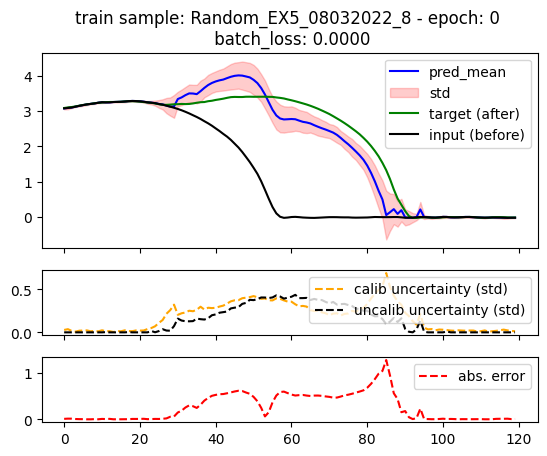

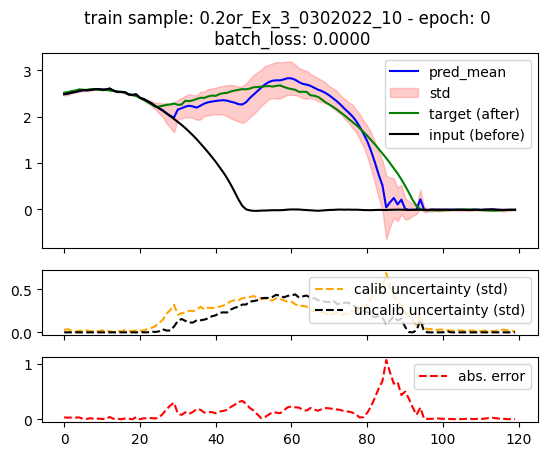

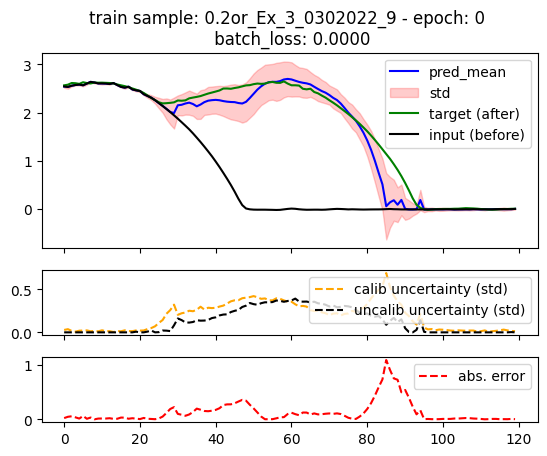

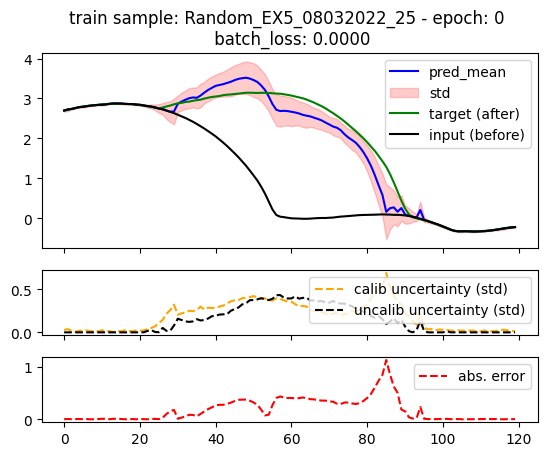

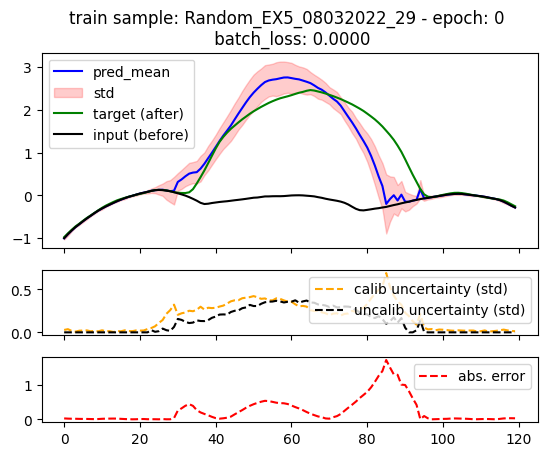

In [55]:
# choose n indices from range(n_samples) at random
n_samples, n_features = val_calibrated_uncertainties.shape
n = 10
indices = np.random.choice(range(n_samples), n, replace=False)

for b in indices:
    pred_mean = val_mean_predictions[b]
    std = val_uncertainties[b]
    calib_std = val_calibrated_uncertainties[b]
    error = val_errors[b]
    trgt = val_ys[b]
    inpt = val_xs[b]
    id_ = val_ids[b]
    batch_loss = 0
    epoch = 0
    stage = "train"
    _plot_example(pred_mean, calib_std, std, error, trgt, inpt, id_, batch_loss, epoch, stage)
    plt.show()